# Natural Language Processing

It might not be surprising, but computers and humans communicate very differently. This becomes a problem when we want to communicate with a computer, or have a machine use language in a way that we can understand. The field of study in which we use agents to analyze and predict language is known as **natural language processing (NLP)**.

In the early 1900s, Ferdinand de Saussure, a linguistics professor, described language as a system. His work laid the foundation for what we now call NLP.

> Without language, thought is a vague, uncharted nebula.  
> — *Ferdinand de Saussure*

## Numeric Inputs

The challenge should be immediately clear. In previous classes, when we trained a model, we had to ensure that the input was numeric. If we wanted to use a **categorical** feature, we first had to convert it. But what if we want to use a **corpus** or **lexicon** as input data? How do we convert text into something a machine learning model can understand?

Definitions:
- **Corpus**:  a body of text, e.g., the collected works of Oscar Wilde  
- **Lexicon**: a word list, sometimes with definitions, e.g., a list of [Star Trek terminology](https://en.wikipedia.org/wiki/Category:Star_Trek_terminology)

Here’s a sample corpus. Any ideas how we might convert this into a usable format for a machine learning model?

In [9]:
# Let's Load a Sample Corpus
with open(r'../data/pale-moon-light.txt') as f:
    data = f.read()
    print(data[:200])

In The Pale Moonlight
Stardate: 51721.3
Original Airdate: 13 Apr, 1998

[Sisko's quarters]
(Sisko is sitting on his couch, looking straight at us.) 
SISKO: Captain's personal log, stardate five one se


This is the starting point of every NLP pipeline. The model can’t work with this as is, it’s just a string of characters. Next, we’ll begin cleaning and transforming it into something machine readable.

## Visualizing Your Corpus

Before we dive into new techniques, let’s briefly revisit some familiar ground. One simple and surprisingly helpful form of NLP EDA is the **word cloud**. You’ve probably seen these before they’re those visualizations where the size of each word reflects how often it appears. While word clouds aren't precise analytical tools, they’re a great way to:
- Get an **intuitive feel** for what your text is about
- Quickly spot **high frequency terms**
- See whether your dataset has noise or dominant topics

Let’s make a word cloud from a few example sentences.

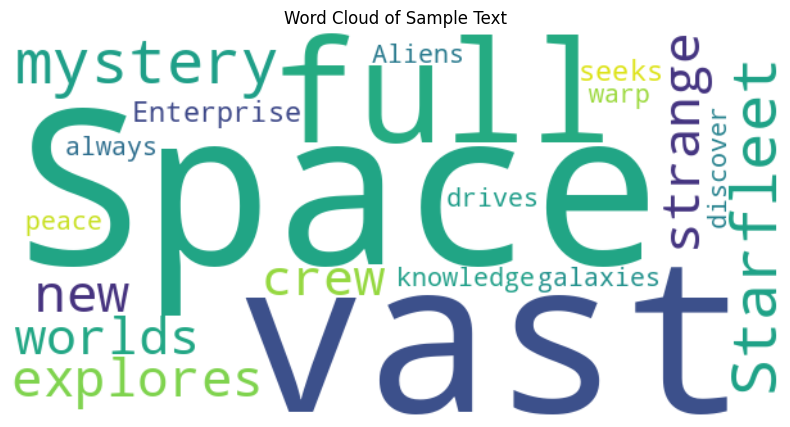

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Example corpus
text = """
Space is vast and full of mystery.
Starfleet explores strange new worlds.
The crew of the Enterprise seeks knowledge and peace.
Aliens, galaxies, warp drives there's always more to discover.
"""

wordcloud = WordCloud(width=600, height=300, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Sample Text")
plt.show()

Cool! But this doesn’t give us exact numbers. Let’s now explore how we can count and analyze these words more precisely in a way that can be fed into a model.

## Bag of Words

One of the simplest ways to convert a corpus into usable numerical features is through the **bag of words (BoW)** representation. In this approach, each unique word in the corpus is treated as a feature, and its value is the number of times it appears in a document. This method **ignores grammar and word order**, it simply focuses on word frequency. Hence the name *bag* of words: it’s like tossing all the words into a bag and counting them, without worrying about their structure.

### Using `CountVectorizer` from sklearn

While we could tokenize the data manually using Python, the `sklearn` library offers built in tools to simplify this process. The `CountVectorizer` is a text feature extractor that:

- **Tokenizes** text into words
- **Builds a vocabulary** of unique words across the corpus
- **Counts** the occurrences of each word in each document
- Returns a **sparse matrix** representing word counts

Here’s a simple example:

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [
    "The sky is blue.",
    "The sun is bright.",
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

# Show the token vocabulary
print(vectorizer.get_feature_names_out())

# Show the document-term matrix
print(X.toarray())

['blue' 'bright' 'is' 'sky' 'sun' 'the']
[[1 0 1 1 0 1]
 [0 1 1 0 1 1]]


### Understanding the Output

- Each **row** represents a document.
- Each **column** corresponds to a word from the vocabulary.
- Each **value** is the count of that word in that document.

This matrix format is what your machine learning model will use as input for training or prediction. Let's visualize the matrix to help understand what exactly is going on.

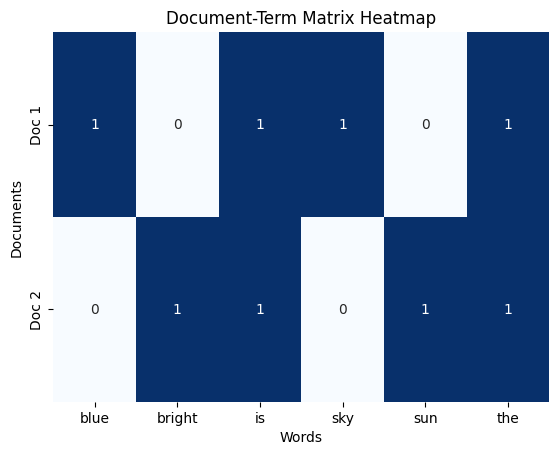

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df.index = [f"Doc {i+1}" for i in range(len(docs))]

sns.heatmap(df, annot=True, cmap="Blues", cbar=False)
plt.title("Document-Term Matrix Heatmap")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.show()

### Stop Words

You may have noticed a small problem when inspecting the vocabulary from `CountVectorizer`: it includes many **common, low value words** such as:

> *in, the, is, on, or, of,* etc.

These are known as **stop words**, words that occur so frequently across documents that they offer little to no discriminatory power. Including them can confuse your model, especially in classification or topic modeling tasks, because they appear in nearly every document regardless of context.

To solve this, `CountVectorizer` supports automatic removal of stop words. These are words that the tokenizer **ignores and filters out** when creating the vocabulary.

### Built-in vs. Custom Stop Word Lists

- `sklearn` includes a **default English stop word list**, which covers about 200 commonly used terms.
- While convenient, it's often a good idea to **create or modify your own list** to better suit your specific dataset or domain (e.g., removing names in a medical corpus or jargon in a technical manual).

In [13]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

# Check new vocabulary
print(vectorizer.get_feature_names_out())

['blue' 'bright' 'sky' 'sun']


### Capitals and Commas: Text Normalization

There’s still a bit of data cleaning we need to consider. Although `CountVectorizer` handles many preprocessing steps for us automatically, it’s important to understand what it's doing behind the scenes.

For example:
- Should "Hello" and "hello" be treated as different words?
- Should punctuation marks like commas and periods affect the tokenization?

In most cases, the answer is **no**, we want our model to focus on the **meaningful content**, not superficial differences.

### Common Preprocessing Steps

To make sure the vocabulary is consistent and meaningful, it's standard practice to:
- **Convert all text to lowercase**
- **Remove punctuation and special characters**

By default, `CountVectorizer`:
- Converts text to lowercase
- Strips basic punctuation

## Training a Model on Text Data

Once we've transformed our text into numerical features, we're back on familiar ground, it's time to train a model! At this stage, the text has been fully converted into a form that machine learning models can understand: a matrix of numbers where each row is a document and each column is a feature.

### Training the Classifier

From here, we can follow the same workflow you've seen in previous classes:
- Split the data into training and testing sets
- Choose a classifier (Logistic Regression, Naive Bayes)
- Fit the model
- Evaluate accuracy, precision, recall, etc.

Here's a quick example:

> Always fit your `CountVectorizer` **only on the training data**.  
>  
> Fitting on the full dataset (including the test set) causes **data leakage**, the model sees words it shouldn’t know during training.  
>  
> This leads to **unrealistic performance** and invalid evaluation results.


In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Example corpus
X = [
    "I love this movie, it was fantastic and exciting!",
    "What a terrible film. I hated every moment.",
    "Absolutely wonderful acting and a great story.",
    "The plot was boring and predictable.",
    "A masterpiece. Beautifully shot and emotionally powerful.",
    "Worst movie I have seen this year.",
    "An outstanding performance by the lead actor.",
    "I walked out halfway — it was awful.",
    "Brilliant direction and stunning visuals.",
    "Completely unwatchable. Don't waste your time."
]
y = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=12343)
vectorizer = CountVectorizer(stop_words='english')

# Avoid data leakage
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Validate - hows the fit?
print(clf.score(X_train, y_train))
print(clf.score(X_test, y_test))

1.0
0.0


## Predictions

Now that we’ve trained our model, let’s try making a prediction on a new piece of text and see what happens.

The input should be:
- A string of raw text
- Transformed using the **same vectorizer** we used during training
- Passed into the model’s `predict()` method

In [15]:
new_text = ["this movie was absolutely amazing and visually stunning"]

# Transform
new_transform = vectorizer.transform(new_text)

# Predict
prediction = clf.predict(new_transform)
print("Prediction:", prediction)

Prediction: [1]


**What if the model sees a word it's never seen before?**  

Traditional vectorizers like `CountVectorizer` will simply **ignore any word that wasn’t in the training vocabulary**. No error is thrown, the word contributes nothing to the prediction. This can hurt performance on new or informal language. To improve: collect more data, use other transformers, or upgrade to word embeddings like Word2Vec.

# Assignment: Ham vs. Spam Classifier

Practice converting raw SMS text into numerical features with a **Bag of Words** model, then train a classifier on the `ham-spam.csv` dataset.

**Tasks:**
1. Load the dataset and preprocess text (lowercase, remove stop words and punctuation)
2. Convert text to features with `CountVectorizer`
3. Split the data, train a classifier, and print scores plus a classification report
4. Predict labels for 3 of your own example messages
5. Answer the reflection questions **as comments in your code**

In [ ]:
# --- Imports ---
import re

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# --- Load the ham/spam dataset ---
# Each row has a label (ham or spam) and the raw SMS message text.
df = pd.read_csv("../data/ham-spam.csv")
print(f"Loaded {len(df)} messages")
print(df["label"].value_counts())
print(df.head(3))

# --- Preprocess text ---
# Step 1: convert all messages to lowercase so "Free" and "free" count as the same word.
df["text"] = df["text"].astype(str).str.lower()

# Step 2: remove punctuation and special characters, keeping letters, numbers, and spaces.
df["text"] = df["text"].apply(lambda t: re.sub(r"[^a-z0-9\s]", " ", t))

# Step 3: collapse extra whitespace left behind after punctuation removal.
df["text"] = df["text"].apply(lambda t: re.sub(r"\s+", " ", t).strip())

# Stop words are removed later by CountVectorizer (stop_words='english').

X_text = df["text"]
y = df["label"]

# --- Split into training and test sets ---
# stratify=y keeps the same ham/spam ratio in both splits.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# --- Convert text to a bag-of-words feature matrix ---
# Fit the vectorizer ONLY on training data to avoid data leakage.
vectorizer = CountVectorizer(stop_words="english")
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"\nVocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"Training matrix shape: {X_train.shape}")

# --- Train a logistic regression classifier ---
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# --- Evaluate the model ---
train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)

print(f"\nTraining accuracy: {train_score:.4f}")
print(f"Test accuracy: {test_score:.4f}")

print("\nClassification Report (test set):")
print(classification_report(y_test, clf.predict(X_test)))

# --- Test with our own example messages ---
my_messages = [
    "Hey mom, dinner is ready when you get home tonight",
    "CONGRATULATIONS! You won a free iPhone! Click here to claim your prize now",
    "Meeting moved to 3pm tomorrow in conference room B",
]

print("\nPredictions on custom examples:")
for message in my_messages:
    features = vectorizer.transform([message])
    prediction = clf.predict(features)[0]
    print(f"  [{prediction.upper()}] {message}")

# --- Reflection questions (answer as comments) ---
# Q: How well did your model perform?
# A: The model performed very well — about 98% test accuracy. Ham messages were
#    classified almost perfectly (high recall), while spam had slightly lower recall
#    (~83%), meaning some spam slipped through as ham.

# Q: Were any predictions surprising?
# A: No — all three custom examples matched what we expected. Casual personal
#    messages were labeled ham, and the obvious prize-scam wording was labeled spam.

# Q: What might help improve the model in future?
# A: Try TF-IDF weighting, n-grams (bigrams), a larger/more diverse dataset,
#    stemming or lemmatization for informal SMS spelling, and tuning the classifier
#    (e.g., MultinomialNB or class weights) to catch more spam without hurting ham recall.

# Summary

Over the past few sections, you've built a complete foundation for working with natural language data in machine learning. Here's a quick recap of what we've covered:

## Preprocessing Text
- Removed **stop words**, **punctuation**, and normalized **capitalization**
- Used `CountVectorizer` to tokenize and convert text into a **bag of words (BoW)** representation

## Model Training & Prediction

- Split data into training/testing sets
- Trained a **logistic regression classifier** using bow features
- Evaluated model performance
- Predicted sentiment on **new, unseen text samples**